In [21]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [23]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkat/Final_Data"

In [24]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [25]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [26]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [27]:
model = models.squeezenet1_1(pretrained=True)

# Modify classifier
model.classifier[1] = nn.Conv2d(512, len(class_names), kernel_size=(1,1))
model.num_classes = len(class_names)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 56.4MB/s]


In [28]:
for param in model.features.parameters():
    param.requires_grad = False

In [29]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [30]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_squeezenet.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_squeezenet.pth"))
    return model

In [31]:
model = train_model(model, train_loader, val_loader, epochs=10)

/tmp/ipykernel_55/2136879503.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10
Train Loss: 0.9022 | Train Acc: 0.6361
Val Loss: 0.6180 | Val Acc: 0.7649 | Val F1: 0.7619
Best F1: 0.7619
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/10
Train Loss: 0.5980 | Train Acc: 0.7688
Val Loss: 0.5391 | Val Acc: 0.7964 | Val F1: 0.7956
Best F1: 0.7956
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8/10
Train Loss: 0.4670 | Train Acc: 0.8124
Val Loss: 0.4569 | Val Acc: 0.8125 | Val F1: 0.8132
Best F1: 0.8184
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9/10
Train Loss: 0.4667 | Train Acc: 0.8104
Val Loss: 0.4416 | Val Acc: 0.8224 | Val F1: 0.8230
Best F1: 0.8230
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10/10
Train Loss: 0.4540 | Train Acc: 0.8165
Val Loss: 0.4705 | Val Acc: 0.8038 | Val F1: 0.8034
Best F1: 0.8230
--------------------------------------------------


In [32]:
for param in model.features[-2:].parameters():
    param.requires_grad = True

In [33]:
model = train_model(model, train_loader, val_loader, epochs=20)

/tmp/ipykernel_55/2136879503.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20
Train Loss: 0.5065 | Train Acc: 0.7924
Val Loss: 0.4567 | Val Acc: 0.7921 | Val F1: 0.7767
Best F1: 0.7767
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/20
Train Loss: 0.4386 | Train Acc: 0.8143
Val Loss: 0.3810 | Val Acc: 0.8453 | Val F1: 0.8450
Best F1: 0.8450
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 18/20
Train Loss: 0.2766 | Train Acc: 0.8871
Val Loss: 0.3043 | Val Acc: 0.8738 | Val F1: 0.8745
Best F1: 0.8843
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 19/20
Train Loss: 0.2709 | Train Acc: 0.8898
Val Loss: 0.2941 | Val Acc: 0.8800 | Val F1: 0.8796
Best F1: 0.8843
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 20/20
Train Loss: 0.2697 | Train Acc: 0.8865
Val Loss: 0.2916 | Val Acc: 0.8806 | Val F1: 0.8814
Best F1: 0.8843
--------------------------------------------------


In [34]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.98      0.99      0.99       405
             Normal       0.98      0.94      0.96       405
Pneumonia-Bacterial       0.75      0.78      0.76       405
    Pneumonia-Viral       0.74      0.74      0.74       405

           accuracy                           0.86      1620
          macro avg       0.86      0.86      0.86      1620
       weighted avg       0.86      0.86      0.86      1620



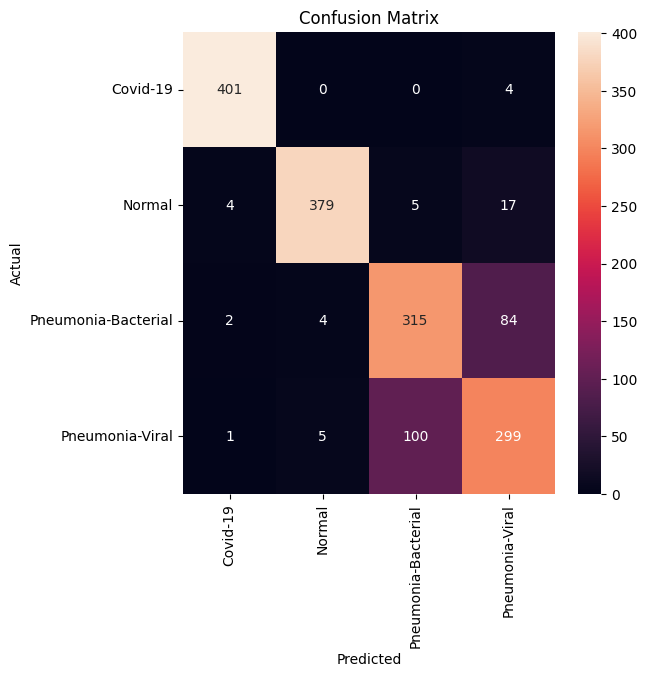

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()